<a href="https://colab.research.google.com/github/CodeBlue0001/Agrimind/blob/main/crops_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [3]:
# loading dataset
df=pd.read_csv("/content/sensor_Crop_Dataset (1).csv")
df=pd.DataFrame(df)
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [4]:
Wheat = df.loc[df['Crop'] == 'Wheat']
Wheat

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
8,70.295205,56.440554,86.625145,16.437203,89.183316,6.447732,68.940764,Wheat,Sandy,Hard Red
16,19.498481,68.835789,25.207968,40.940690,41.905561,7.540588,282.847326,Wheat,Loamy,Soft Red
27,137.924406,33.503446,87.901294,30.696630,36.302131,6.847548,212.010203,Wheat,Sandy,Hard Red
31,20.744780,82.716496,68.034689,12.392061,67.457672,8.291505,316.299112,Wheat,Peaty,Hard Red
...,...,...,...,...,...,...,...,...,...,...
19992,102.545320,41.574596,50.404115,43.363820,42.472312,7.251172,50.560143,Wheat,Silt,Soft Red
19994,105.188471,74.797471,44.355085,42.574152,56.385680,8.329246,130.789838,Wheat,Peaty,Durum
19996,29.790472,17.182611,74.772890,40.974020,83.002347,5.895767,333.470901,Wheat,Clay,Durum
19997,25.001919,19.140862,32.719994,29.001299,55.231845,8.230164,119.351274,Wheat,Loamy,Hard Red


In [5]:
# analyzing data for diffrent variety of wheat
softRed=Wheat.loc[Wheat['Variety']=='Soft Red']
softRed

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
16,19.498481,68.835789,25.207968,40.940690,41.905561,7.540588,282.847326,Wheat,Loamy,Soft Red
48,21.641006,49.700299,48.940160,21.353955,92.046884,4.630371,221.348093,Wheat,Saline,Soft Red
69,21.540409,78.217392,19.808399,43.001374,74.893032,5.343010,318.026546,Wheat,Saline,Soft Red
92,84.744728,84.030351,91.526018,36.892463,98.324597,5.134442,186.960883,Wheat,Sandy,Soft Red
...,...,...,...,...,...,...,...,...,...,...
19867,27.283293,28.115110,45.047700,42.847046,60.562647,6.913134,222.313870,Wheat,Peaty,Soft Red
19932,149.363227,16.096758,54.617523,30.161667,94.784611,4.565040,73.868594,Wheat,Loamy,Soft Red
19969,29.261366,46.591530,48.984741,35.518859,76.703040,7.363448,343.347530,Wheat,Loamy,Soft Red
19992,102.545320,41.574596,50.404115,43.363820,42.472312,7.251172,50.560143,Wheat,Silt,Soft Red


In [6]:
# data processing for clay soil
clay=softRed.loc[softRed['Soil_Type']=='Clay']
clay

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
128,26.442777,41.068994,61.285032,41.549439,45.943874,7.076784,23.148993,Wheat,Clay,Soft Red
386,22.814475,87.376686,94.656564,34.890156,55.089468,7.868538,156.212661,Wheat,Clay,Soft Red
487,97.156282,29.575308,54.998772,43.885854,83.410052,6.175359,144.111733,Wheat,Clay,Soft Red
742,32.602750,19.913354,37.272060,32.794717,64.375459,7.090910,185.581273,Wheat,Clay,Soft Red
...,...,...,...,...,...,...,...,...,...,...
19042,57.155624,76.721749,53.937559,39.106072,66.820849,7.907981,37.550077,Wheat,Clay,Soft Red
19118,71.078477,37.704295,77.734553,26.627581,82.126135,5.614110,162.849753,Wheat,Clay,Soft Red
19331,44.370801,9.265320,30.299318,17.932985,37.460918,6.933571,360.637664,Wheat,Clay,Soft Red
19664,85.813226,55.941347,87.167573,41.665692,43.073566,5.556481,63.730877,Wheat,Clay,Soft Red


In [7]:
min_rainfall = clay['Rainfall'].min()
max_rainfall = clay['Rainfall'].max()

print(f"Minimum Rainfall in clay dataset: {min_rainfall:.2f}")
print(f"Maximum Rainfall in clay dataset: {max_rainfall:.2f}")

Minimum Rainfall in clay dataset: 22.33
Maximum Rainfall in clay dataset: 399.91


In [8]:
rainfall_bins = [20, 150, 280, 400]
rainfall_labels = ['Low Rainfall', 'Medium Rainfall', 'High Rainfall']
clay['Rainfall_Category'] = pd.cut(clay['Rainfall'], bins=rainfall_bins, labels=rainfall_labels, right=False)

display(clay.head())

/tmp/ipykernel_2778/1344443296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clay['Rainfall_Category'] = pd.cut(clay['Rainfall'], bins=rainfall_bins, labels=rainfall_labels, right=False)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety,Rainfall_Category
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red,High Rainfall
128,26.442777,41.068994,61.285032,41.549439,45.943874,7.076784,23.148993,Wheat,Clay,Soft Red,Low Rainfall
386,22.814475,87.376686,94.656564,34.890156,55.089468,7.868538,156.212661,Wheat,Clay,Soft Red,Medium Rainfall
487,97.156282,29.575308,54.998772,43.885854,83.410052,6.175359,144.111733,Wheat,Clay,Soft Red,Low Rainfall
742,32.602750,19.913354,37.272060,32.794717,64.375459,7.090910,185.581273,Wheat,Clay,Soft Red,Medium Rainfall


Now, let's plot Nitrogen vs. Phosphorus for each rainfall category within the `clay` dataset.

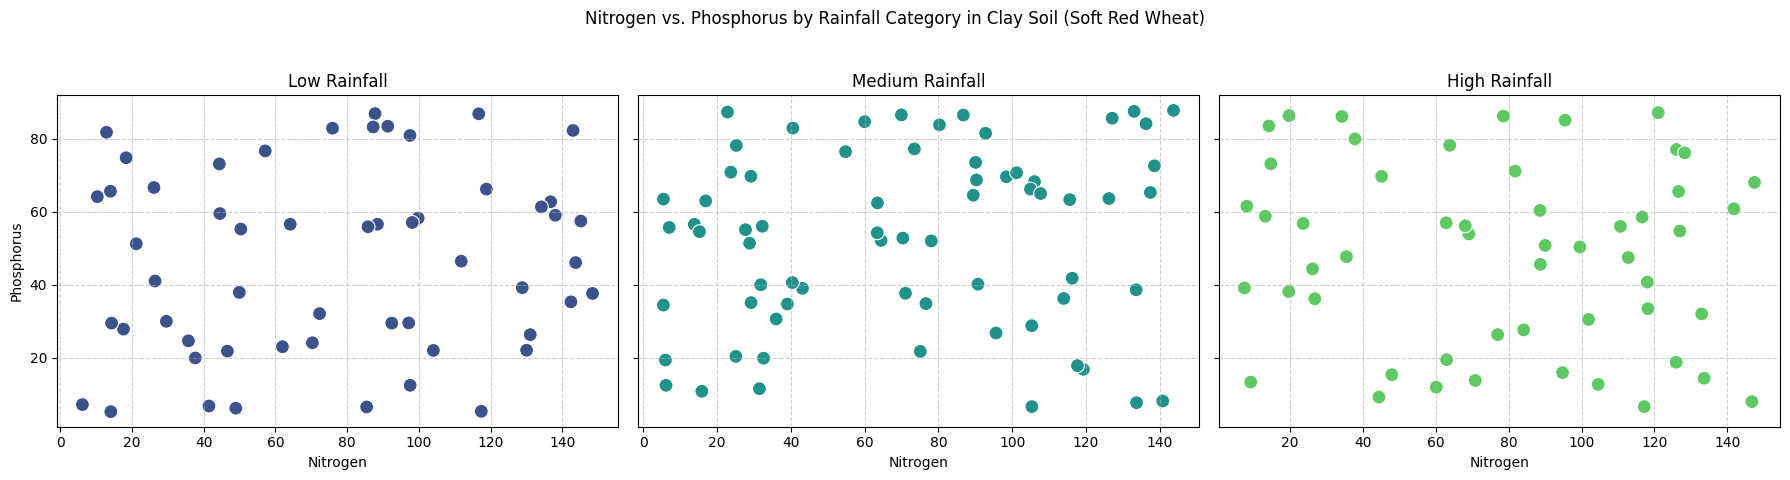

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Nitrogen vs. Phosphorus by Rainfall Category in Clay Soil (Soft Red Wheat)')

for i, category in enumerate(rainfall_labels):
    subset = clay[clay['Rainfall_Category'] == category]
    sns.scatterplot(ax=axes[i], x='Nitrogen', y='Phosphorus', data=subset, hue='Rainfall_Category', palette='viridis', s=100, legend=False)
    axes[i].set_title(category)
    axes[i].set_xlabel('Nitrogen')
    if i == 0:
        axes[i].set_ylabel('Phosphorus')
    else:
        axes[i].set_ylabel('')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df.drop('Crop', axis=1)
y = df['Crop']

# Identify categorical and numerical features
categorical_features = ['Soil_Type', 'Variety']
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and a RandomForestClassifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Save the model and encoder for future use (e.g., chatbot interface)
import joblib
joblib.dump(model_pipeline, 'crop_prediction_model.pkl')
joblib.dump(label_encoder, 'crop_label_encoder.pkl')

print("\nModel and label encoder saved as 'crop_prediction_model.pkl' and 'crop_label_encoder.pkl'.")
print("You can now load these to make new predictions, for example, in a chatbot interface.")

Model Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

       Maize       1.00      1.00      1.00       679
      Potato       1.00      1.00      1.00       675
        Rice       1.00      1.00      1.00       641
   Sugarcane       1.00      1.00      1.00       616
      Tomato       1.00      1.00      1.00       677
       Wheat       1.00      1.00      1.00       712

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


Model and label encoder saved as 'crop_prediction_model.pkl' and 'crop_label_encoder.pkl'.
You can now load these to make new predictions, for example, in a chatbot interface.


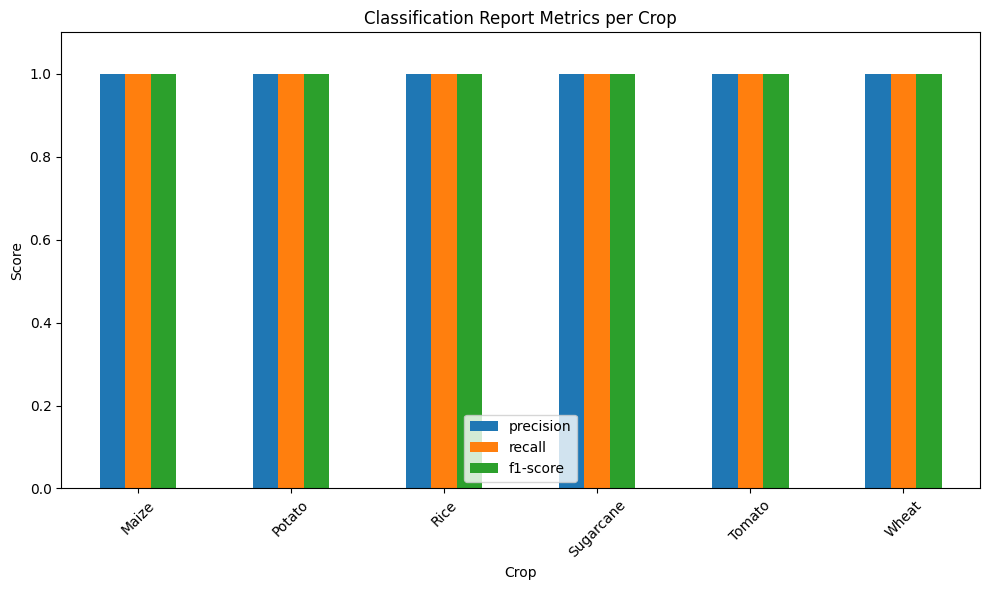

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Get classification report as a dictionary
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)

# Convert to DataFrame for easier plotting, excluding 'accuracy', 'macro avg', 'weighted avg'
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(columns=['support'])

# Filter out aggregate rows for plotting individual class metrics
df_report_classes = df_report.loc[label_encoder.classes_]

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report_classes.plot(kind='bar', ax=ax)
ax.set_title('Classification Report Metrics per Crop')
ax.set_ylabel('Score')
ax.set_xlabel('Crop')
ax.set_ylim(0, 1.1) # Set y-limit to clearly show scores between 0 and 1
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Load the saved model and make a prediction

In [12]:
import joblib
import pandas as pd

# Load the saved model and label encoder
loaded_model_pipeline = joblib.load('crop_prediction_model.pkl')
loaded_label_encoder = joblib.load('crop_label_encoder.pkl')

print("Model and label encoder loaded successfully.")

# Define new input data for prediction
# You can modify these values to test different conditions
new_data = pd.DataFrame([
    {
        'Nitrogen': 180,
        'Phosphorus': 100,
        'Potassium': 0,
        'Temperature': 20,
        'Humidity': 90,
        'pH_Value': 7.5,
        'Rainfall': 200,
        'Soil_Type': 'Clay',
        'Variety': ''
    }
])

# Make a prediction using the loaded model
predicted_crop_encoded = loaded_model_pipeline.predict(new_data)

# Decode the predicted crop back to its original name
predicted_crop_name = loaded_label_encoder.inverse_transform(predicted_crop_encoded)

print(f"\nInput Conditions:\n{new_data.to_string(index=False)}")
print(f"\nPredicted Crop: {predicted_crop_name[0]}")

Model and label encoder loaded successfully.

Input Conditions:
 Nitrogen  Phosphorus  Potassium  Temperature  Humidity  pH_Value  Rainfall Soil_Type Variety
      180         100          0           20        90       7.5       200      Clay        

Predicted Crop: Rice


### Crop Condition Recommendation Model

This section will help in recommending adjustments to soil nutrients (N, P, K) and pH values for a specific crop to achieve optimal growth, based on the characteristics observed in the dataset for that crop.

In [13]:
def get_optimal_ranges(crop_name, dataframe):
    """
    Calculates the optimal ranges (min, max) for NPK, pH, Temperature, Humidity, and Rainfall
    for a given crop based on the provided dataframe.
    """
    crop_data = dataframe[dataframe['Crop'] == crop_name]

    if crop_data.empty:
        print(f"No data found for crop: {crop_name}")
        return None

    optimal_ranges = {}
    for feature in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH_Value', 'Temperature', 'Humidity', 'Rainfall']:
        optimal_ranges[feature] = {
            'min': crop_data[feature].min(),
            'max': crop_data[feature].max()
        }
    return optimal_ranges

print("Function 'get_optimal_ranges' defined.")

Function 'get_optimal_ranges' defined.


In [18]:
def recommend_soil_adjustments(current_conditions, optimal_ranges):
    """
    Recommends adjustments to soil and environmental conditions for a crop.
    `current_conditions` should be a dictionary with keys: 'Nitrogen', 'Phosphorus', 'Potassium', 'pH_Value', 'Temperature', 'Humidity', 'Rainfall'.
    `optimal_ranges` should be the output from `get_optimal_ranges`.
    """
    recommendations = []
    for feature in ['Nitrogen', 'Phosphorus', 'Potassium', 'pH_Value', 'Temperature', 'Humidity', 'Rainfall']:
        current_val = current_conditions.get(feature)
        optimal_min = optimal_ranges[feature]['min']
        optimal_max = optimal_ranges[feature]['max']

        if current_val is None:
            recommendations.append(f"Missing current value for {feature}. Optimal range: {optimal_min:.2f} - {optimal_max:.2f}.")
            continue

        if current_val < optimal_min:
            recommendations.append(f"Current {feature} ({current_val:.4f}) is too low. Consider increasing it. Optimal range: {optimal_min:.4f} - {optimal_max:.4f}.")
        elif current_val > optimal_max:
            recommendations.append(f"Current {feature} ({current_val:.4f}) is too high. Consider decreasing it. Optimal range: {optimal_min:.4f} - {optimal_max:.4f}.")
        else:
            recommendations.append(f"Current {feature} ({current_val:.4f}) is within the optimal range ({optimal_min:.4f} - {optimal_max:.4f}).")

    if not recommendations:
        return "No specific recommendations needed based on the provided conditions and optimal ranges."
    else:
        return "\n".join(recommendations)

print("Function 'recommend_soil_adjustments' defined.")

Function 'recommend_soil_adjustments' defined.


#### Example Usage of the Recommendation Model

In [19]:
# Define the target crop for recommendations
target_crop = 'Rice'

# Get optimal ranges for the target crop
rice_optimal_ranges = get_optimal_ranges(target_crop, df)

if rice_optimal_ranges:
    print(f"\nOptimal Ranges for {target_crop}:")
    for feature, ranges in rice_optimal_ranges.items():
        print(f"  {feature}: {ranges['min']:.2f} - {ranges['max']:.2f}")

    # Define example current conditions (you can change these values)
    current_conditions_rice = {
        'Nitrogen': 50,
        'Phosphorus': 80,
        'Potassium': 30,
        'pH_Value': 9,
        'Temperature': 40,
        'Humidity': 85,
        'Rainfall': 250
    }

    print(f"\nCurrent Conditions for {target_crop}:")
    for feature, value in current_conditions_rice.items():
        print(f"  {feature}: {value}")

    # Get recommendations
    recommendations = recommend_soil_adjustments(current_conditions_rice, rice_optimal_ranges)
    print(f"\nRecommendations for {target_crop}:\n{recommendations}")
else:
    print("Could not get optimal ranges for the specified crop.")


Optimal Ranges for Rice:
  Nitrogen: 5.01 - 149.89
  Phosphorus: 5.04 - 89.98
  Potassium: 10.02 - 99.96
  pH_Value: 4.50 - 8.50
  Temperature: 10.00 - 45.00
  Humidity: 30.06 - 99.95
  Rainfall: 20.24 - 399.81

Current Conditions for Rice:
  Nitrogen: 50
  Phosphorus: 80
  Potassium: 30
  pH_Value: 9
  Temperature: 40
  Humidity: 85
  Rainfall: 250

Recommendations for Rice:
Current Nitrogen (50.0000) is within the optimal range (5.0096 - 149.8924).
Current Phosphorus (80.0000) is within the optimal range (5.0410 - 89.9816).
Current Potassium (30.0000) is within the optimal range (10.0234 - 99.9604).
Current pH_Value (9.0000) is too high. Consider decreasing it. Optimal range: 4.5001 - 8.4999.
Current Temperature (40.0000) is within the optimal range (10.0048 - 44.9974).
Current Humidity (85.0000) is within the optimal range (30.0607 - 99.9489).
Current Rainfall (250.0000) is within the optimal range (20.2409 - 399.8129).


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
